# Tutorial: Block-Wise Beta Estimation → MVPA Decoding
## neuroclass2026 MVPA Workshop

This notebook walks through the **complete single-subject pipeline**:

```
1. Block-design events   → LSA beta estimation (one beta per trial block)
2. Beta images (3D)      → feature matrix  X  (n_trials × n_voxels)
3. Feature matrix        → ANOVA feature selection
4. Selected features     → SVM classifier  (Leave-One-Run-Out CV)
5. CV accuracy           → permutation test for significance
6. Fitted weights        → brain-space importance map
```

**Helper script:** `fmri_helpers.py` — call `list_helpers()` at any time  
to print all available functions and their signatures.

> **Exercise cells** are marked `# ── EXERCISE ──` and contain `raise NotImplementedError(...)`.  
> Fill in the code, then re-run. Check cells directly below each exercise  
> print a quick sanity check so you know if your answer is on the right track.


---
## Section 0 — Setup & Configuration

In [1]:
# PROVIDED — run this cell first
import os, warnings, time
import numpy as np
import pandas as pd
import nibabel as nib
from pathlib import Path
from contextlib import contextmanager

from nilearn import image
from nilearn.maskers import NiftiMasker
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.feature_selection import SelectFpr, SelectKBest, f_classif
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Import all helpers
import sys
sys.path.insert(0, ".")            # adjust path if fmri_helpers.py is elsewhere

import importlib
import fmri_helpers

# Run this after you make changes to my_module.py
importlib.reload(fmri_helpers)

from fmri_helpers import *

# Print available helpers
list_helpers()



████████████████████████████████████████████████████████████████████████
                   fmri_helpers — Available Functions                   
████████████████████████████████████████████████████████████████████████

  ┌─ Module 1 — Preprocessing ──────────────────────────────────────────
  │  load_bold_and_mask(bold_path: 'str', mask_path: 'str', n_dummy_scans: ...
  │      → Load a 4-D BOLD NIfTI and its brain mask, optionally dropping dummy scans.
  │
  │  load_confounds(confound_tsv: 'str', strategy: 'str' = 'hmp24', fd_...
  │      → Load confound regressors from an fMRIPrep confounds TSV file.
  │
  │  compute_fd(hmp_array: 'np.ndarray', brain_radius_mm: 'float' =...
  │      → Compute framewise displacement from head motion parameters.
  │
  │  clean_bold_run(bold_img: 'nib.Nifti1Image', mask_img: 'nib.Nifti1I...
  │      → Apply polynomial detrending + confound regression to one BOLD run.
  │
  │  plot_motion_qc(fd_per_run: 'List[np.ndarray]', tsnr_before: 'List[...
  │    

In [2]:
# PROVIDED — edit paths for your subject
SUBJECT  = "sub-1"
TASK     = "objectviewing"
TR       = 2.5      # seconds
N_RUNS   = 12

BIDS_ROOT    = "/pl/active/courses/2026_summer/neuroclass2026/ds000105"
FMRIPREP_DIR = f"{BIDS_ROOT}/derivatives/fmriprep"
CLEAN_DIR    = f"{BIDS_ROOT}/derivatives/preprocessed/{SUBJECT}"
BETA_DIR   = f"{BIDS_ROOT}/derivatives/beta_weights/{SUBJECT}"
WARPED_DIR = f"{BETA_DIR}/warped_masks"
OUTPUT_DIR   = f"{BIDS_ROOT}/derivatives/mvpa_blockdesign/{SUBJECT}"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# Build per-run path lists
run_ids = list(range(1, N_RUNS + 1))

bold_files = [
    f"{CLEAN_DIR}/{SUBJECT}_task-{TASK}_run-{r}_desc-hmp24_bold.nii.gz"
    for r in run_ids
]

events_files = [
    f"{BIDS_ROOT}/{SUBJECT}/func/"
    f"{SUBJECT}_task-{TASK}_run-{r:02d}_events.tsv"
    for r in run_ids
]


# ── Common intersection mask (produced by tutorial_03a_mask_warping.ipynb) ───
MASK_FILE = (
    f"{WARPED_DIR}/{SUBJECT}_task-objectviewing"
    f"_desc-warpedGroupMaskCommon_funcspace.nii.gz"
)

print(f"Subject : {SUBJECT}")
print(f"Runs    : {run_ids}")
print(f"Output  : {OUTPUT_DIR}")


Subject : sub-1
Runs    : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Output  : /pl/active/courses/2026_summer/neuroclass2026/ds000105/derivatives/mvpa_blockdesign/sub-1


---
## Section 1 — Load Events & Inspect the Block Design

Each run has a BIDS `_events.tsv` with columns `onset`, `duration`, `trial_type`.  
In a **block design**, consecutive trials of the same condition form a block.  
The LSA GLM will assign one HRF-convolved regressor to each trial; we later average  
betas within a block (or treat each trial separately) as features for the classifier.

**Your task below:** load the events files and compute the number of trials  
per condition per run.


In [3]:
# PROVIDED — load events files
events_per_run = []
for path in events_files:
    df = pd.read_csv(path, sep='\t')
    events_per_run.append(df)

# Peek at run 1
print(events_per_run[0].head(10))
print(f"\nColumns: {list(events_per_run[0].columns)}")
print(f"Conditions: {events_per_run[0]['trial_type'].unique()}")


   onset  duration trial_type
0   12.0       0.5   scissors
1   14.0       0.5   scissors
2   16.0       0.5   scissors
3   18.0       0.5   scissors
4   20.0       0.5   scissors
5   22.0       0.5   scissors
6   24.0       0.5   scissors
7   26.0       0.5   scissors
8   28.0       0.5   scissors
9   30.0       0.5   scissors

Columns: ['onset', 'duration', 'trial_type']
Conditions: <ArrowStringArray>
['scissors', 'face', 'cat', 'shoe', 'house', 'scrambledpix', 'bottle',
 'chair']
Length: 8, dtype: str


In [4]:
# ── Helper ────────────────────────────────────────────────────────────────────
@contextmanager
def track_runtime(label="block"):
    t0 = time.perf_counter()
    try:
        yield
    finally:
        print(f"  [{label}] {time.perf_counter()-t0:.1f}s")


def _load_bold(path, n_dummy_scans=0):
    img = nib.load(path)
    if n_dummy_scans > 0:
        img = image.index_img(img, slice(n_dummy_scans, None))
    return img


def _load_events(path, run_idx, conditions=None):
    ev = pd.read_csv(path, sep='\t')
    missing = {'onset', 'duration', 'trial_type'} - set(ev.columns)
    if missing:
        raise ValueError(f"Run {run_idx + 1} events file missing columns: {missing}")
    if conditions:
        ev = ev[ev['trial_type'].isin(conditions)].copy()
    return ev.reset_index(drop=True)


def _apply_block_grouping(ev):
    ev_blocked = events_to_blocks(ev)
    summary = "  →  " + ", ".join(
        f"{cond}: {len(g)} block(s) from {g['n_trials'].sum()} trial(s)"
        for cond, g in ev_blocked.groupby('trial_type')
    )
    return ev_blocked, summary


# ── Load BOLD, masks, and events ──────────────────────────────────────────────
use_block_regressors = True
events_per_run = []

for ri, path in enumerate(events_files):
    ev       = _load_events(path, ri)
    n_trials = len(ev)

    block_summary = ""
    if use_block_regressors:
        ev, block_summary = _apply_block_grouping(ev)

    events_per_run.append(ev)
#     print(
#         f"  Run {ri+1:>2d}: {n_trials} trial(s)"
#         + (f" → {len(ev)} block(s)" if use_block_regressors else "")
#         + f"  | types: {sorted(ev['trial_type'].unique())}"
#         + (f"\n         {block_summary}" if use_block_regressors else "")
#     )

# Peek at run 1
print(events_per_run[0].head(10))
print(f"\nColumns: {list(events_per_run[0].columns)}")
print(f"Conditions: {events_per_run[0]['trial_type'].unique()}")

CONDITIONS = sorted({t for ev in events_per_run for t in ev['trial_type']})
n_runs     = len(events_files)
print(f"\nRuns: {n_runs}  |  Conditions: {CONDITIONS}")

   onset  duration    trial_type  n_trials
0   12.0      22.5      scissors        12
1   48.0      22.5          face        12
2   84.0      22.5           cat        12
3  120.0      22.5          shoe        12
4  156.0      22.5         house        12
5  192.0      22.5  scrambledpix        12
6  228.0      22.5        bottle        12
7  264.0      22.5         chair        12

Columns: ['onset', 'duration', 'trial_type', 'n_trials']
Conditions: <ArrowStringArray>
['scissors', 'face', 'cat', 'shoe', 'house', 'scrambledpix', 'bottle',
 'chair']
Length: 8, dtype: str

Runs: 12  |  Conditions: ['bottle', 'cat', 'chair', 'face', 'house', 'scissors', 'scrambledpix', 'shoe']


In [5]:
# ── ANSWER: Exercise 1 ───────────────────────────────────────────────────────
# Add a 'run' column to each per-run events DataFrame, concatenate, then pivot.

all_events_df = pd.concat(
    [df.assign(run=run_id) for run_id, df in zip(run_ids, events_per_run)],
    ignore_index=True,
)

trial_counts = (
    all_events_df
    .groupby(['run', 'trial_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .rename_axis(None, axis=1)
)

print("Trial counts per run:")
print(trial_counts.to_string(index=False))

# Sanity check: every run should have the same number of trials per condition
assert len(trial_counts) == N_RUNS
print(f"\n✓  {N_RUNS} runs, {len(trial_counts.columns) - 1} conditions")


Trial counts per run:
 run  bottle  cat  chair  face  house  scissors  scrambledpix  shoe
   1       1    1      1     1      1         1             1     1
   2       1    1      1     1      1         1             1     1
   3       1    1      1     1      1         1             1     1
   4       1    1      1     1      1         1             1     1
   5       1    1      1     1      1         1             1     1
   6       1    1      1     1      1         1             1     1
   7       1    1      1     1      1         1             1     1
   8       1    1      1     1      1         1             1     1
   9       1    1      1     1      1         1             1     1
  10       1    1      1     1      1         1             1     1
  11       1    1      1     1      1         1             1     1
  12       1    1      1     1      1         1             1     1

✓  12 runs, 8 conditions


---
## Section 2 — LSA Beta Estimation (Block Design)

**Least Squares All (LSA):** one GLM is fit per run.  
Each trial receives its own uniquely-labelled HRF regressor.  
The resulting beta coefficient captures the BOLD response for that individual trial.

`fit_lsa_run()` from `fmri_helpers` does this in one call:
```python
betas = fit_lsa_run(bold_img, events_df, mask_img, tr=TR)
# betas  →  dict: trial_idx  →  {img, condition, onset, run}
```

The function:
1. Relabels each trial as `<condition>__trial_<N>` (unique regressor)
2. Builds the design matrix with cosine/polynomial drift
3. Fits a `FirstLevelModel` with AR(1) noise
4. Extracts one `effect_size` contrast image per trial

**Your task:** call `fit_lsa_run` for each run and collect all betas.


In [6]:
# PROVIDED — load BOLD images and masks (will take a moment)
print_section("Loading BOLD data")

bold_imgs, mask_imgs = [], []
for bold_f in bold_files:
    bold_img = nib.load(bold_f)
    mask_img = nib.load(MASK_FILE)
    bold_imgs.append(bold_img)
    mask_imgs.append(mask_img)
    print(f"  {Path(bold_f).name}  {bold_img.shape}")

print(f"\n{len(bold_imgs)} runs loaded")



  Loading BOLD data
  sub-1_task-objectviewing_run-1_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)
  sub-1_task-objectviewing_run-2_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)
  sub-1_task-objectviewing_run-3_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)
  sub-1_task-objectviewing_run-4_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)
  sub-1_task-objectviewing_run-5_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)
  sub-1_task-objectviewing_run-6_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)
  sub-1_task-objectviewing_run-7_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)
  sub-1_task-objectviewing_run-8_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)
  sub-1_task-objectviewing_run-9_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)
  sub-1_task-objectviewing_run-10_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)
  sub-1_task-objectviewing_run-11_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)
  sub-1_task-objectviewing_run-12_desc-hmp24_bold.nii.gz  (40, 64, 64, 121)

12 runs loaded


In [7]:
# ── ANSWER: Exercise 2 ───────────────────────────────────────────────────────
# Loop over runs, call fit_lsa_run, and collect betas in a flat dict
# keyed by (run_id, trial_idx).

all_betas = {}

for run_id, bold_img, events_df, mask_img in zip(
        run_ids, bold_imgs, events_per_run, mask_imgs):

    with track_runtime(f"Run {run_id:02d} LSA"):
        run_betas = fit_lsa_run(
            bold_img  = bold_img,
            events_df = events_df,
            mask_img  = mask_img,
            tr        = TR,
            hrf_model = 'spm',
            high_pass = None,
            run_id    = run_id,
        )

    for trial_idx, beta_info in run_betas.items():
        all_betas[(run_id, trial_idx)] = beta_info

print(f"\nTotal beta images: {len(all_betas)}")
# Quick sanity check
sample_key = list(all_betas.keys())[0]
print(f"Example key: {sample_key},  condition: {all_betas[sample_key]['condition']}")


  [Run 01 LSA] 0.9s
  [Run 02 LSA] 0.9s
  [Run 03 LSA] 0.9s
  [Run 04 LSA] 0.9s
  [Run 05 LSA] 1.0s
  [Run 06 LSA] 0.9s
  [Run 07 LSA] 0.9s
  [Run 08 LSA] 0.9s
  [Run 09 LSA] 0.9s
  [Run 10 LSA] 0.9s
  [Run 11 LSA] 0.9s
  [Run 12 LSA] 0.9s

Total beta images: 96
Example key: (1, 0),  condition: scissors


---
## Section 3 — Build the Feature Matrix

The classifier operates on a 2-D matrix:

| Dimension | Meaning |
|-----------|---------|
| **rows** (axis 0) | Trials — one row per beta image |
| **columns** (axis 1) | Voxels — one column per in-mask voxel |

`stack_betas_from_dict()` from `fmri_helpers` handles this:
```python
X, y_raw, runs_arr, masker = stack_betas_from_dict(all_betas, mask_img)
# X         → (n_trials, n_voxels)  float32
# y_raw     → (n_trials,)           string condition labels
# runs_arr  → (n_trials,)           int run index (for LORO-CV)
# masker    → fitted NiftiMasker    (use masker.inverse_transform later)
```

**Your task:** call the helper and inspect the output.


In [8]:
# ── ANSWER: Exercise 3 ───────────────────────────────────────────────────────
# stack_betas_from_dict sorts entries by (run_id, trial_idx), fits a
# NiftiMasker on the first image, and returns a float32 feature matrix.

X, y_raw, runs_arr, masker = stack_betas_from_dict(
    betas_dict = all_betas,
    mask_img   = mask_imgs[0],   # reference mask — all runs share the same space
)

le = LabelEncoder()
y  = le.fit_transform(y_raw)

print(f"X shape      : {X.shape}  (n_trials × n_voxels)")
print(f"Conditions   : {le.classes_}")
print(f"Runs         : {np.unique(runs_arr)}")
print(f"Chance level : {100 / len(le.classes_):.1f}%")

# Verify
assert X.ndim == 2
assert len(y_raw) == X.shape[0]
assert len(runs_arr) == X.shape[0]
print("\n✓  Feature matrix looks correct")


  Feature matrix: 96 trials × 6152 voxels
X shape      : (96, 6152)  (n_trials × n_voxels)
Conditions   : ['bottle' 'cat' 'chair' 'face' 'house' 'scissors' 'scrambledpix' 'shoe']
Runs         : [ 1  2  3  4  5  6  7  8  9 10 11 12]
Chance level : 12.5%

✓  Feature matrix looks correct


---
## Section 4 — Feature Selection (ANOVA)

With ~50,000 voxels and only ~96 trials, running SVM on the full matrix  
is slow and overfits. We select a subset of voxels using a univariate  
**ANOVA F-test** (one-way across conditions).

**Important:** feature selection must be applied *inside* each CV fold  
(fit on training set, transform both train and test). The sklearn  
`Pipeline` handles this automatically.

Here, we first inspect the F-score map on all data (no leakage risk  
for inspection only); the actual selection inside the CV pipeline  
is always re-fit on each training fold.

**Your task:** compute F-scores and select the top `anova_p` fraction.


In [9]:
# ── ANSWER: Exercise 4 ───────────────────────────────────────────────────────
# Fit SelectFpr on ALL data just for inspection — not used inside the CV loop.
# The real selection happens inside the Pipeline per fold.

anova_alpha = 0.05

selector_inspect = SelectFpr(f_classif, alpha=anova_alpha)
selector_inspect.fit(X, y)

n_selected   = int(selector_inspect.get_support().sum())
pct_selected = 100.0 * n_selected / X.shape[1]

print(f"Total voxels     : {X.shape[1]}")
print(f"ANOVA α          : {anova_alpha}")
print(f"Voxels selected  : {n_selected}  ({pct_selected:.1f}%)")
print(f"Voxels discarded : {X.shape[1] - n_selected}  ({100 - pct_selected:.1f}%)")

# Note: this number will differ slightly between folds inside the Pipeline
# because each fold uses a different (smaller) training set to fit the F-test.
print("\n✓  Selector fitted (inspection only — not used in CV)")


Total voxels     : 6152
ANOVA α          : 0.05
Voxels selected  : 808  (13.1%)
Voxels discarded : 5344  (86.9%)

✓  Selector fitted (inspection only — not used in CV)


---
## Section 5 — Build the CV Pipeline & Splitter

We wrap **feature selection + classifier** in a `sklearn.Pipeline`  
so both steps are consistently applied within each CV fold.

```
Pipeline:
  step 1 — feature_selection : SelectFpr(f_classif, alpha=0.05)
  step 2 — svm               : SVC(kernel='linear', C=1.0, class_weight='balanced')
```

Cross-validation: **Leave-One-Run-Out (LORO)**  
Each fold holds out one entire run as the test set and trains on the remaining runs.  
This preserves temporal autocorrelation across runs and avoids data leakage.

**Your task:** construct the pipeline and CV splitter.


In [10]:
# ── ANSWER: Exercise 5 ───────────────────────────────────────────────────────

pipe = Pipeline([
    ('feature_selection', SelectFpr(f_classif, alpha=0.05)),
    ('svm', SVC(
        C            = 1.0,
        kernel       = 'linear',
        class_weight = 'balanced',   # handles mild class imbalance
        random_state = 42,
    )),
])

cv     = LeaveOneGroupOut()
groups = runs_arr   # one group label per trial — defines the CV folds

n_folds = len(np.unique(runs_arr))
print(f"Pipeline steps  : {list(pipe.named_steps.keys())}")
print(f"CV              : LeaveOneGroupOut  ({n_folds} folds)")
print(f"groups shape    : {groups.shape},  unique runs: {np.unique(groups)}")
print("\n✓  Pipeline and splitter ready")


Pipeline steps  : ['feature_selection', 'svm']
CV              : LeaveOneGroupOut  (12 folds)
groups shape    : (96,),  unique runs: [ 1  2  3  4  5  6  7  8  9 10 11 12]

✓  Pipeline and splitter ready


---
## Section 6 — Run Cross-Validation & Compute Accuracy

`cross_val_predict` runs the full pipeline on each fold:
- Fits `feature_selection` on the training set
- Transforms both train and test through the selector
- Fits the SVM on the (selected) training features
- Predicts on the held-out test set

We collect predictions and then compute accuracy per fold.

**Your tasks:**
1. Run `cross_val_predict` to get trial-wise predictions `y_pred`
2. Loop over folds to compute per-fold accuracy, mean, and SEM


In [11]:
# ── ANSWER: Exercise 6a ──────────────────────────────────────────────────────
# cross_val_predict handles train/test splitting, feature selection, and
# SVM fitting inside each fold. n_jobs=-1 parallelises across folds.

with track_runtime("LORO cross-validation"):
    y_pred = cross_val_predict(
        pipe, X, y,
        cv     = cv,
        groups = groups,
        n_jobs = -1,
    )

overall_acc = accuracy_score(y, y_pred)
bal_acc     = balanced_accuracy_score(y, y_pred)

print(f"Predictions shape  : {y_pred.shape}")
print(f"Overall accuracy   : {overall_acc*100:.1f}%")
print(f"Balanced accuracy  : {bal_acc*100:.1f}%")
print(f"Chance level       : {100/len(le.classes_):.1f}%")


  [LORO cross-validation] 6.9s
Predictions shape  : (96,)
Overall accuracy   : 51.0%
Balanced accuracy  : 51.0%
Chance level       : 12.5%


In [12]:
# ── ANSWER: Exercise 6b ──────────────────────────────────────────────────────
# Iterate over folds manually to get per-fold accuracy numbers.
# (cross_val_predict gives trial-level predictions but not fold-level stats.)

fold_accs = []

for fold_i, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=groups)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipe.fit(X_train, y_train)
    y_pred_fold = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred_fold)
    fold_accs.append(acc)

mean_acc = np.mean(fold_accs)
sem_acc  = np.std(fold_accs, ddof=1) / np.sqrt(len(fold_accs))
chance   = 1.0 / len(le.classes_)

print("Per-fold accuracies:")
for fold_i, acc in enumerate(fold_accs):
    bar = '█' * int(acc * 40)
    print(f"  Run {fold_i+1:>2d}: {acc*100:5.1f}%  {bar}")

print(f"\nMean ± SEM      : {mean_acc*100:.1f}% ± {sem_acc*100:.1f}%")
print(f"Chance          : {chance*100:.1f}%")
print(f"Above chance by : {(mean_acc - chance)*100:.1f} pp")


Per-fold accuracies:
  Run  1:  50.0%  ████████████████████
  Run  2:  37.5%  ███████████████
  Run  3:  50.0%  ████████████████████
  Run  4:  50.0%  ████████████████████
  Run  5:  50.0%  ████████████████████
  Run  6:  62.5%  █████████████████████████
  Run  7:  50.0%  ████████████████████
  Run  8:  37.5%  ███████████████
  Run  9:  37.5%  ███████████████
  Run 10:  37.5%  ███████████████
  Run 11:  75.0%  ██████████████████████████████
  Run 12:  75.0%  ██████████████████████████████

Mean ± SEM      : 51.0% ± 3.9%
Chance          : 12.5%
Above chance by : 38.5 pp


---
## Section 7 — Permutation Test

**Why permutation testing?**  
Accuracy alone does not tell you whether performance exceeds chance at a  
statistically rigorous level. We build a **null distribution** by shuffling  
class labels and re-running the full CV pipeline many times.

```
Null distribution:  
  for i in range(n_permutations):
      y_perm = shuffle(y)
      null_acc[i] = cross_val_predict(pipe, X, y_perm, cv, groups)

p-value = proportion of null_accs ≥ observed mean_acc
```

> **Note on label shuffling:**  
> We shuffle within runs to preserve run structure.  
> All shuffled runs must still produce valid class proportions.

**Your tasks:**
1. Write the permutation loop
2. Compute the p-value


In [13]:
# ── ANSWER: Exercise 7a ──────────────────────────────────────────────────────
# Shuffle labels, re-run CV, collect null distribution of accuracies.
# Note: we use run_permutation_test from fmri_helpers for efficiency,
# but the manual loop is shown below for transparency.

N_PERMUTATIONS = 1000
rng            = np.random.default_rng(seed=42)
null_accs      = []

print(f"Running {N_PERMUTATIONS} permutations ...")
t0 = time.perf_counter()

for i in range(N_PERMUTATIONS):
    y_perm      = rng.permutation(y)
    y_perm_pred = cross_val_predict(
        pipe, X, y_perm, cv=cv, groups=groups, n_jobs=-1)
    null_accs.append(accuracy_score(y_perm, y_perm_pred))

    if (i + 1) % 200 == 0:
        elapsed = time.perf_counter() - t0
        eta     = elapsed / (i + 1) * (N_PERMUTATIONS - i - 1)
        print(f"  {i+1:>4d}/{N_PERMUTATIONS}  "
              f"null mean so far: {np.mean(null_accs)*100:.2f}%  "
              f"ETA: {eta/60:.1f} min")

null_accs = np.array(null_accs)
print(f"\nDone in {(time.perf_counter()-t0)/60:.1f} min")
print(f"Null distribution: {null_accs.mean()*100:.2f}% ± {null_accs.std()*100:.2f}%")


Running 1000 permutations ...
   200/1000  null mean so far: 10.52%  ETA: 1.8 min
   400/1000  null mean so far: 10.91%  ETA: 1.4 min
   600/1000  null mean so far: 11.03%  ETA: 0.9 min
   800/1000  null mean so far: 10.97%  ETA: 0.5 min
  1000/1000  null mean so far: 11.02%  ETA: 0.0 min

Done in 2.3 min
Null distribution: 11.02% ± 3.52%


In [14]:
# ── ANSWER: Exercise 7b ──────────────────────────────────────────────────────
# p-value = proportion of null accuracies >= observed.
# Floor at 1/N_PERMUTATIONS because p=0 is not achievable empirically.

p_value = float(max(
    (null_accs >= mean_acc).mean(),
    1.0 / (N_PERMUTATIONS+1),
))

# Pretty-print p-value
if p_value < 0.001:
    p_str = f"< 0.001  (floor: 1/{N_PERMUTATIONS})"
else:
    p_str = f"= {p_value:.4f}"

print(f"Observed accuracy    : {mean_acc*100:.2f}%")
print(f"Null mean            : {null_accs.mean()*100:.2f}%")
print(f"Null 95th percentile : {np.percentile(null_accs, 99.9)*100:.2f}%")
print(f"p-value              : {p_str}")
print(f"Significant (α=0.05) : {'YES ✓' if p_value < 0.05 else 'NO ✗'}")


Observed accuracy    : 51.04%
Null mean            : 11.02%
Null 95th percentile : 21.88%
p-value              : < 0.001  (floor: 1/1000)
Significant (α=0.05) : YES ✓


95th percentile of null : 17.71%
Observed accuracy       : 51.04%
Observed EXCEEDS ✓ the threshold (Δ = +33.33 pp)


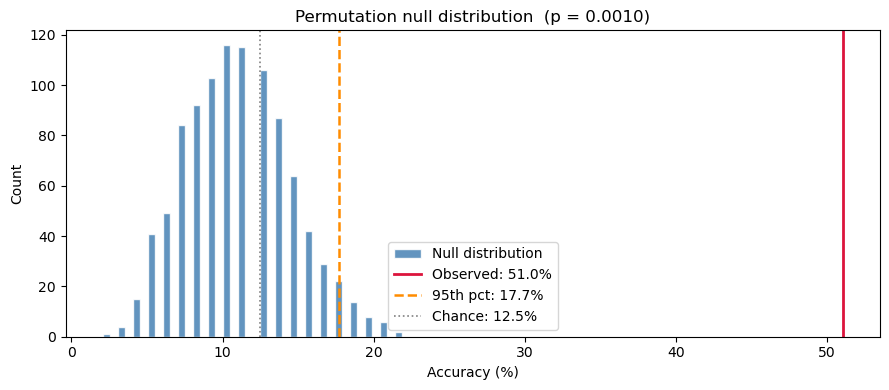

In [15]:
# ── ANSWER: Exercise 7c ──────────────────────────────────────────────────────
# The 95th percentile of the null distribution is the critical threshold:
# any observed accuracy above this value corresponds to p < 0.05.

threshold_95 = float(np.percentile(null_accs, 95))

print(f"95th percentile of null : {threshold_95*100:.2f}%")
print(f"Observed accuracy       : {mean_acc*100:.2f}%")
print(f"Observed {'EXCEEDS ✓' if mean_acc > threshold_95 else 'does NOT exceed ✗'} "
      f"the threshold (Δ = {(mean_acc - threshold_95)*100:+.2f} pp)")

# Visualise the null distribution
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(null_accs * 100, bins=40, color='steelblue', edgecolor='white',
        alpha=0.85, label='Null distribution')
ax.axvline(mean_acc * 100, color='crimson', lw=2,
           label=f'Observed: {mean_acc*100:.1f}%')
ax.axvline(threshold_95 * 100, color='darkorange', lw=1.8, ls='--',
           label=f'95th pct: {threshold_95*100:.1f}%')
ax.axvline(chance * 100, color='gray', lw=1.2, ls=':',
           label=f'Chance: {chance*100:.1f}%')
ax.set_xlabel('Accuracy (%)'); ax.set_ylabel('Count')
ax.set_title(f'Permutation null distribution  (p = {p_value:.4f})')
ax.legend(); plt.tight_layout(); plt.show()


---
## Section 8 — Classifier Importance Map

For a **linear SVM**, the weight vector `w` (from `clf.coef_`) encodes  
how strongly each voxel contributed to the decision boundary.  
Mapping `|w|` back to brain space gives an *importance map*.

Steps:
1. Fit the pipeline on **all** training data (not fold-wise)
2. Extract `pipe['svm'].coef_`  — shape: `(n_hyperplanes, n_selected_voxels)`
3. Average absolute weights across hyperplanes → `(n_selected_voxels,)`
4. Expand back through the feature selector → `(n_mask_voxels,)`
5. Call `masker.inverse_transform()` → 3-D NIfTI

`compute_importance_map()` in `fmri_helpers` automates steps 2–5.

**Your task:** fit the final pipeline and produce the importance map.


In [16]:
# ── ANSWER: Exercise 8a ──────────────────────────────────────────────────────
# Re-fit the pipeline on ALL trials so we can extract the SVM weight vector.
# This is separate from CV — we use all data to get the most stable weights.

pipe.fit(X, y)

coef = pipe['svm'].coef_
print(f"Pipeline fitted on full dataset  ({X.shape[0]} trials)")
print(f"SVM coef_ shape : {coef.shape}")
print(f"  → {coef.shape[0]} hyperplanes × {coef.shape[1]} selected voxels")
print(f"  ({coef.shape[0]} = C(n_classes, 2) one-vs-one pairs "
      f"for {len(le.classes_)} conditions)")


Pipeline fitted on full dataset  (96 trials)
SVM coef_ shape : (28, 808)
  → 28 hyperplanes × 808 selected voxels
  (28 = C(n_classes, 2) one-vs-one pairs for 8 conditions)


Importance map shape  : (40, 64, 64)
Non-zero voxels       : 808
Max weight            : 0.0275
Saved → /pl/active/courses/2026_summer/neuroclass2026/ds000105/derivatives/mvpa_blockdesign/sub-1/sub-1_importance_map.nii.gz


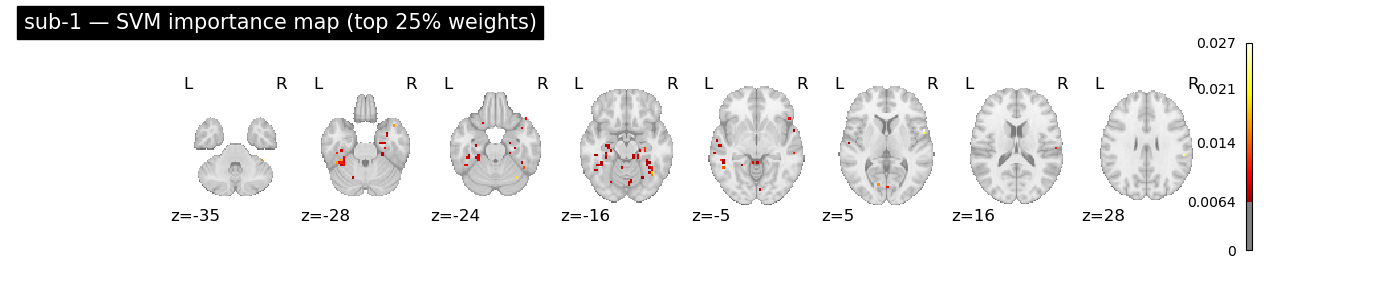

In [17]:
# ── ANSWER: Exercise 8b ──────────────────────────────────────────────────────
# compute_importance_map averages |coef_| across hyperplanes, expands through
# the feature selector back to mask space, and calls masker.inverse_transform.

# active_voxels: boolean array over mask voxels — which are non-zero in X.
# If stack_betas_from_dict already dropped zero-variance voxels, pass accordingly.
# Here we assume no additional dropping was done by the masker.
active_voxels = np.ones(X.shape[1], dtype=bool)
n_mask_voxels = X.shape[1]

importance_img = compute_importance_map(
    pipe          = pipe,
    X             = X,
    masker        = masker,
    active_voxels = active_voxels,
    n_mask_voxels = n_mask_voxels,
)

# Save
imp_path = os.path.join(OUTPUT_DIR, f"{SUBJECT}_importance_map.nii.gz")
importance_img.to_filename(imp_path)

imp_data = importance_img.get_fdata()
print(f"Importance map shape  : {importance_img.shape}")
print(f"Non-zero voxels       : {(imp_data > 0).sum()}")
print(f"Max weight            : {imp_data.max():.4f}")
print(f"Saved → {imp_path}")

# Quick visualisation
from nilearn import plotting
fig, ax = plt.subplots(figsize=(14, 3))
plotting.plot_stat_map(
    importance_img,
    display_mode = 'z',
    cut_coords   = 8,
    colorbar     = True,
    cmap         = 'hot',
    threshold    = float(np.percentile(imp_data[imp_data > 0], 75)),
    title        = f'{SUBJECT} — SVM importance map (top 25% weights)',
    axes         = ax,
)
plt.tight_layout(); plt.show()


---
## Section 9 — Summary & Save Results


In [18]:
# PROVIDED — save a results JSON and print summary
results = dict(
    subject         = SUBJECT,
    n_trials        = int(X.shape[0]),
    n_features_raw  = int(X.shape[1]),
    n_features_sel  = int(pipe['feature_selection'].get_support().sum()),
    n_conditions    = int(len(le.classes_)),
    conditions      = list(le.classes_),
    cv              = "LeaveOneRunOut",
    n_folds         = int(len(fold_accs)),
    fold_accs       = [round(float(a), 4) for a in fold_accs],
    mean_acc        = round(float(mean_acc), 4),
    sem_acc         = round(float(sem_acc), 4),
    chance          = round(float(chance), 4),
    n_permutations  = N_PERMUTATIONS,
    p_value         = round(float(p_value), 4),
    significant     = bool(p_value < 0.05),
    importance_map  = imp_path,
)

import json
results_path = os.path.join(OUTPUT_DIR, "mvpa_results.json")
with open(results_path, "w") as fh:
    json.dump(results, fh, indent=2)

print_section("MVPA Results Summary")
for k, v in results.items():
    if k not in ('fold_accs', 'conditions'):
        print(f"  {k:<22}: {v}")
print(f"\nResults saved → {results_path}")



  MVPA Results Summary
  subject               : sub-1
  n_trials              : 96
  n_features_raw        : 6152
  n_features_sel        : 808
  n_conditions          : 8
  cv                    : LeaveOneRunOut
  n_folds               : 12
  mean_acc              : 0.5104
  sem_acc               : 0.0391
  chance                : 0.125
  n_permutations        : 1000
  p_value               : 0.001
  significant           : True
  importance_map        : /pl/active/courses/2026_summer/neuroclass2026/ds000105/derivatives/mvpa_blockdesign/sub-1/sub-1_importance_map.nii.gz

Results saved → /pl/active/courses/2026_summer/neuroclass2026/ds000105/derivatives/mvpa_blockdesign/sub-1/mvpa_results.json


---
## Appendix — Key Concepts

### Why LSA for block designs?
In a block design, trials are spaced far apart (long ITIs or rest periods),  
so the HRF responses are largely orthogonal. LSA has low collinearity between  
trial regressors, making each beta a reliable estimate of the trial-evoked response.  
LSS (Least Squares Separate) is unnecessary here — it is primarily useful when ITI < 4 s.

### Why Leave-One-Run-Out CV?
fMRI data within a run are temporally autocorrelated. Training and testing  
on the same run would inflate accuracy estimates. LORO-CV uses entire runs as  
fold units, ensuring that no temporal leakage occurs between train and test.

### Permutation test vs parametric test
- The null distribution from permutations is **non-parametric**: it makes no  
  assumption about the distribution of accuracy.
- Label shuffling preserves the structure of X (brain patterns) and CV scheme.
- `p_value < 1/N_PERMUTATIONS` is reported as `p < 0.001` (floor).

### Importance maps — caveats
- Linear SVM weights reflect contributions to **one specific decision boundary**.  
  Multi-class SVMs produce one weight vector per hyperplane (one-vs-one or one-vs-rest).
- `|w|` is not a measure of univariate response; it captures *discriminative* information.
- Do **not** threshold importance maps without group-level statistics (see `group_importance_maps.ipynb`).
